In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import sys
sys.path.append(f"./../")

# Import the BWT module
from src.bwt import QuantumWalkBWT

In [2]:
def compare_theory_numerical(height=3, num_samples=200):
    """
    Compare theoretical and numerical exit probabilities for BWT quantum walk.

    Args:
        height (int): Height of the Binary Welded Tree
        num_samples (int): Number of time points to sample

    Returns:
        dict: Results of the comparison
    """
    print(f"=== BWT Quantum Walk Comparison (height={height}) ===")

    # Initialize quantum walk
    start_time = time.time()
    print("Initializing Binary Welded Tree and Hamiltonian...")
    qwalk = QuantumWalkBWT(height=height)
    print(f"Initialization completed in {time.time() - start_time:.2f} seconds")
    print(f"Number of vertices in BWT: {qwalk.n_vertices}")

    # Calculate theoretical optimal time
    optimal_t = np.pi * (2 * height + 1) / 2
    print(f"Theoretical optimal time: {optimal_t:.4f}")

    # Calculate exit probability at optimal time
    print("\nCalculating exit probability at optimal time...")
    num_prob = qwalk.exit_probability(optimal_t)
    theo_prob = qwalk.theoretical_exit_probability(optimal_t)

    print(f"  Numerical: {num_prob:.6f}")
    print(f"  Theoretical: {theo_prob:.6f}")
    print(f"  Absolute difference: {abs(num_prob - theo_prob):.6f}")
    print(f"  Relative difference: {abs(num_prob - theo_prob)/theo_prob*100:.2f}%")

    # Plot exit probability over time
    print("\nGenerating exit probability plot...")
    t_max = 2 * optimal_t

    # Sample more points around the expected peak for better resolution
    t_values_standard = np.linspace(0, t_max, num_samples)
    t_values_around_peak = np.linspace(0.8 * optimal_t, 1.2 * optimal_t, num_samples // 2)
    t_values = np.sort(np.unique(np.concatenate([t_values_standard, t_values_around_peak])))

    # Calculate probabilities
    print(f"Calculating probabilities for {len(t_values)} time points...")
    start_time = time.time()
    num_probs = [qwalk.exit_probability(t) for t in t_values]
    theo_probs = [qwalk.theoretical_exit_probability(t) for t in t_values]
    print(f"Calculations completed in {time.time() - start_time:.2f} seconds")

    # Find peak values
    max_num_idx = np.argmax(num_probs)
    max_num_t = t_values[max_num_idx]
    max_num_prob = num_probs[max_num_idx]

    max_theo_idx = np.argmax(theo_probs)
    max_theo_t = t_values[max_theo_idx]
    max_theo_prob = theo_probs[max_theo_idx]

    print("\nPeak exit probabilities:")
    print(f"  Numerical peak: {max_num_prob:.6f} at time {max_num_t:.4f}")
    print(f"  Theoretical peak: {max_theo_prob:.6f} at time {max_theo_t:.4f}")
    print(f"  Time difference: {abs(max_num_t - max_theo_t):.4f}")
    print(f"  Probability difference: {abs(max_num_prob - max_theo_prob):.6f}")

    # Plot the results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [3, 1]})

    # Main plot
    ax1.plot(t_values, num_probs, "b-", linewidth=2, label="Numerical")
    ax1.plot(t_values, theo_probs, "r--", linewidth=2, label="Theoretical")
    ax1.axvline(
        x=optimal_t, color="g", linestyle=":", label=f"Expected optimal time: t = {optimal_t:.4f}"
    )

    # Mark peak points
    ax1.plot(max_num_t, max_num_prob, "bo", markersize=8)
    ax1.plot(max_theo_t, max_theo_prob, "ro", markersize=8)

    ax1.annotate(
        f"Max numerical: {max_num_prob:.4f} at t = {max_num_t:.2f}",
        xy=(max_num_t, max_num_prob),
        xytext=(max_num_t - 0.2 * t_max, max_num_prob - 0.2 * max_num_prob),
        arrowprops=dict(arrowstyle="->"),
    )

    ax1.annotate(
        f"Max theoretical: {max_theo_prob:.4f} at t = {max_theo_t:.2f}",
        xy=(max_theo_t, max_theo_prob),
        xytext=(max_theo_t + 0.2 * t_max, max_theo_prob - 0.2 * max_theo_prob),
        arrowprops=dict(arrowstyle="->"),
    )

    ax1.set_title(f"Exit Probability for BWT Quantum Walk (height = {height})")
    ax1.set_ylabel("Probability")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="best")
    ax1.set_xlim(0, t_max)
    ax1.set_ylim(0, 1.05 * max(max_num_prob, max_theo_prob))

    # Difference plot
    diff = np.array(num_probs) - np.array(theo_probs)
    ax2.plot(t_values, diff, "k-", linewidth=1.5)
    ax2.axhline(y=0, color="gray", linestyle="-", alpha=0.5)
    ax2.set_title("Difference (Numerical - Theoretical)")
    ax2.set_xlabel("Time t")
    ax2.set_ylabel("Difference")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, t_max)

    plt.tight_layout()

    # Generate visualizations at key times
    print("\nGenerating quantum state visualizations...")
    visualization_times = [
        0,  # Initial state
        optimal_t * 0.25,  # Quarter way
        optimal_t * 0.5,  # Halfway
        optimal_t * 0.75,  # Three-quarters way
        optimal_t,  # At optimal time
        max_num_t,  # At numerical peak
    ]

    visualizations = []
    for t in visualization_times:
        print(f"  Visualizing state at t = {t:.2f}...")
        vis_fig = qwalk.visualize_quantum_state(t)
        visualizations.append((t, vis_fig))

    return {
        "height": height,
        "n_vertices": qwalk.n_vertices,
        "optimal_time_theoretical": optimal_t,
        "optimal_time_numerical": max_num_t,
        "peak_prob_theoretical": max_theo_prob,
        "peak_prob_numerical": max_num_prob,
        "time_difference": abs(max_num_t - optimal_t),
        "prob_difference": abs(max_num_prob - max_theo_prob),
        "relative_time_diff": abs(max_num_t - optimal_t) / optimal_t,
        "relative_prob_diff": abs(max_num_prob - max_theo_prob) / max_theo_prob,
        "probability_plot": fig,
        "state_visualizations": visualizations,
        "qwalk": qwalk,
    }


def analyze_scaling(heights=[2, 3, 4, 5]):
    """Analyze how optimal time and peak probability scale with BWT height."""
    print("\n=== BWT Quantum Walk Scaling Analysis ===")
    results = []

    for h in heights:
        print(f"\nProcessing BWT with height {h}...")
        result = compare_theory_numerical(height=h, num_samples=100)
        results.append(result)

    # Create summary table
    print("\n=== Scaling Analysis Summary ===")
    print(
        f"{'Height':<8} {'Vertices':<10} {'Theo Time':<12} {'Num Time':<12} {'Theo Prob':<12} {'Num Prob':<12} {'Rel Time Diff':<15} {'Rel Prob Diff':<15}"
    )
    print(
        f"{'------':<8} {'--------':<10} {'---------':<12} {'--------':<12} {'---------':<12} {'--------':<12} {'-------------':<15} {'-------------':<15}"
    )

    for r in results:
        print(
            f"{r['height']:<8} {r['n_vertices']:<10} {r['optimal_time_theoretical']:<12.4f} "
            f"{r['optimal_time_numerical']:<12.4f} {r['peak_prob_theoretical']:<12.6f} "
            f"{r['peak_prob_numerical']:<12.6f} {r['relative_time_diff']*100:<15.2f}% "
            f"{r['relative_prob_diff']*100:<15.2f}%"
        )

    # Create scaling plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Extract data
    h_values = [r["height"] for r in results]
    n_vertices = [r["n_vertices"] for r in results]
    theo_times = [r["optimal_time_theoretical"] for r in results]
    num_times = [r["optimal_time_numerical"] for r in results]
    theo_probs = [r["peak_prob_theoretical"] for r in results]
    num_probs = [r["peak_prob_numerical"] for r in results]

    # Plot time scaling
    ax1.plot(h_values, theo_times, "go-", linewidth=2, label="Theoretical")
    ax1.plot(h_values, num_times, "bo-", linewidth=2, label="Numerical")

    # Linear fit for theoretical times
    x_fit = np.linspace(min(h_values), max(h_values), 100)
    y_fit = np.pi * (2 * x_fit + 1) / 2  # Theoretical formula
    ax1.plot(x_fit, y_fit, "r--", label=r"$\pi(2n+1)/2)")

    ax1.set_title("Optimal Time vs. BWT Height")
    ax1.set_xlabel("Height (n)")
    ax1.set_ylabel("Optimal Time")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot probability scaling
    ax2.plot(h_values, theo_probs, "go-", linewidth=2, label="Theoretical")
    ax2.plot(h_values, num_probs, "bo-", linewidth=2, label="Numerical")

    # Theoretical scaling: 4/(2n+1)^2
    y_fit_prob = 4 / (2 * x_fit + 1) ** 2
    ax2.plot(x_fit, y_fit_prob, "r--", label=r"$4/(2n+1)^2")

    # Log-log inset for probability scaling
    axins = ax2.inset_axes([0.55, 0.55, 0.4, 0.4])
    axins.loglog(h_values, theo_probs, "go-", linewidth=2)
    axins.loglog(h_values, num_probs, "bo-", linewidth=2)
    axins.loglog(x_fit, y_fit_prob, "r--")
    axins.set_title("Log-Log Scale")
    axins.grid(True, alpha=0.3)

    ax2.set_title("Peak Exit Probability vs. BWT Height")
    ax2.set_xlabel("Height (n)")
    ax2.set_ylabel("Peak Probability")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()

    return fig, results


In [3]:
# Create output directory
output_dir = "bwt_results"
os.makedirs(output_dir, exist_ok=True)

# Set the random seed for reproducibility
np.random.seed(42)

def main():
    """Main function to run the quantum walk simulations"""
    print("=" * 50)
    print("BWT Quantum Walk Simulation")
    print("=" * 50)
    
    # Run simulation for a single tree height
    height = 3
    print(f"\nRunning detailed simulation for height = {height}...")
    result = compare_theory_numerical(height=height)
    
    # Save probability plot
    result['probability_plot'].savefig(f"{output_dir}/bwt_exit_probability_h{height}.pdf")
    print(f"Saved exit probability plot to {output_dir}/bwt_exit_probability_h{height}.pdf")
    
    # Save quantum state visualizations
    for t, vis_fig in result['state_visualizations']:
        filename = f"{output_dir}/bwt_state_h{height}_t{t:.2f}.pdf"
        vis_fig.savefig(filename)
        print(f"Saved state visualization at t = {t:.2f} to {filename}")
        plt.close(vis_fig)
    
    # Close probability plot figure
    plt.close(result['probability_plot'])
    
    # Run scaling analysis for multiple heights
    print("\nRunning scaling analysis for multiple tree heights...")
    heights = [2, 3, 4]  # Can add 5 for more comprehensive analysis, but it takes longer
    scaling_fig, scaling_results = analyze_scaling(heights=heights)
    
    # Save scaling figure
    scaling_fig.savefig(f"{output_dir}/bwt_scaling_analysis.pdf")
    print(f"Saved scaling analysis to {output_dir}/bwt_scaling_analysis.pdf")
    plt.close(scaling_fig)
    
    # Generate comparison plot of actual quantum state evolution vs theoretical prediction
    print("\nGenerating comparison of quantum state evolution...")
    generate_quantum_state_comparison(height=3)
    
    print("\nSimulation complete! All results saved to", output_dir)

def generate_quantum_state_comparison(height=3):
    """Generate a side-by-side comparison of quantum state evolution and theoretical prediction"""
    qwalk = QuantumWalkBWT(height=height)
    optimal_t = np.pi * (2*height+1) / 2
    
    # Create a grid of times to visualize
    times = [
        0,                  # Initial state
        optimal_t * 0.25,   # 25% of optimal time
        optimal_t * 0.5,    # 50% of optimal time
        optimal_t * 0.75,   # 75% of optimal time
        optimal_t,          # Optimal time
        optimal_t * 1.25    # 125% of optimal time
    ]
    
    # Create a 2x3 grid of subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f"Quantum State Evolution on BWT (height = {height})", fontsize=16)
    
    # Calculate exit probabilities for all times
    t_values = np.linspace(0, optimal_t*1.5, 100)
    num_probs = [qwalk.exit_probability(t) for t in t_values]
    theo_probs = [qwalk.theoretical_exit_probability(t) for t in t_values]
    
    # Plot exit probability on a smaller subplot
    ax_prob = fig.add_axes([0.15, 0.04, 0.7, 0.15])
    ax_prob.plot(t_values, num_probs, 'b-', linewidth=2, label='Numerical')
    ax_prob.plot(t_values, theo_probs, 'r--', linewidth=2, label='Theoretical')
    
    # Add vertical lines at each time point
    for t in times:
        ax_prob.axvline(x=t, color='g', linestyle=':', alpha=0.7)
    
    ax_prob.set_title('Exit Probability vs Time')
    ax_prob.set_xlabel('Time')
    ax_prob.set_ylabel('Probability')
    ax_prob.grid(True, alpha=0.3)
    ax_prob.legend()
    
    # Plot quantum state at each time
    for i, t in enumerate(times):
        row, col = divmod(i, 3)
        ax = axes[row, col]
        
        # Get quantum state
        psi_t = qwalk.time_evolution(t)
        
        # Extract positions and probabilities
        positions = []
        probabilities = []
        for j, node in enumerate(qwalk.tree.all_nodes):
            positions.append((node.x, node.y))
            probabilities.append(np.abs(psi_t[j])**2)
        
        # Draw edges
        for node in qwalk.tree.all_nodes:
            if node.left:
                ax.plot([node.x, node.left.x], [node.y, node.left.y], 'b-', linewidth=1, alpha=0.3)
            if node.right:
                ax.plot([node.x, node.right.x], [node.y, node.right.y], 'b-', linewidth=1, alpha=0.3)
        
        for node in qwalk.tree.middle_layer_1:
            for zigzag_node in node.zigzag_connections:
                ax.plot([node.x, zigzag_node.x], [node.y, zigzag_node.y], 'r--', 
                        linewidth=1, alpha=0.3)
        
        # Scale marker sizes by probability
        max_size = 500
        for j, ((x, y), prob) in enumerate(zip(positions, probabilities)):
            ax.scatter(x, y, s=prob*max_size, c='b', alpha=0.7)
            
            # Mark entrance and exit
            if j == qwalk.entrance_idx:
                ax.scatter(x, y, s=100, facecolors='none', edgecolors='g', linewidth=2)
                ax.text(x, y+0.05, "Entrance", ha='center', fontsize=10)
            elif j == qwalk.exit_idx:
                ax.scatter(x, y, s=100, facecolors='none', edgecolors='r', linewidth=2)
                ax.text(x, y-0.05, "Exit", ha='center', fontsize=10)
        
        # Calculate exit probability at this time
        exit_prob = np.abs(psi_t[qwalk.exit_idx])**2
        theo_prob = qwalk.theoretical_exit_probability(t)
        
        ax.set_title(f't = {t:.2f}\nExit Prob: {exit_prob:.4f} (Theo: {theo_prob:.4f})')
        ax.axis('equal')
        ax.axis('off')
    
    plt.tight_layout(rect=[0, 0.2, 1, 0.95])
    plt.savefig(f"{output_dir}/bwt_quantum_state_evolution_h{height}.pdf")
    print(f"Saved quantum state evolution to {output_dir}/bwt_quantum_state_evolution_h{height}.pdf")
    plt.close(fig)

BWT Quantum Walk Simulation

Running detailed simulation for height = 3...
=== BWT Quantum Walk Comparison (height=3) ===
Initializing Binary Welded Tree and Hamiltonian...
Initialization completed in 0.00 seconds
Number of vertices in BWT: 30
Theoretical optimal time: 10.9956

Calculating exit probability at optimal time...
  Numerical: 0.270845
  Theoretical: 0.171502
  Absolute difference: 0.099342
  Relative difference: 57.92%

Generating exit probability plot...
Calculating probabilities for 300 time points...
Calculations completed in 0.84 seconds

Peak exit probabilities:
  Numerical peak: 0.852985 at time 3.5363
  Theoretical peak: 0.249278 at time 5.1939
  Time difference: 1.6576
  Probability difference: 0.603707

Generating quantum state visualizations...
  Visualizing state at t = 0.00...
  Visualizing state at t = 2.75...
  Visualizing state at t = 5.50...
  Visualizing state at t = 8.25...
  Visualizing state at t = 11.00...
  Visualizing state at t = 3.54...
Saved exit p

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\examples\./..\src\bwt.py:1485: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)



=== Scaling Analysis Summary ===
Height   Vertices   Theo Time    Num Time     Theo Prob    Num Prob     Rel Time Diff   Rel Prob Diff  
------   --------   ---------    --------     ---------    --------     -------------   -------------  
2        14         7.8540       2.8560       0.343828     0.903554     63.64          % 162.79         %
3        30         10.9956      3.5541       0.248521     0.853999     67.68          % 243.63         %
4        62         14.1372      4.2840       0.203022     0.801316     69.70          % 294.69         %
Saved scaling analysis to bwt_results/bwt_scaling_analysis.pdf

Generating comparison of quantum state evolution...


C:\Users\asshole\AppData\Local\Temp\ipykernel_22808\407130663.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1, 0.95])


Saved quantum state evolution to bwt_results/bwt_quantum_state_evolution_h3.pdf

Simulation complete! All results saved to bwt_results

Total execution time: 11.01 seconds


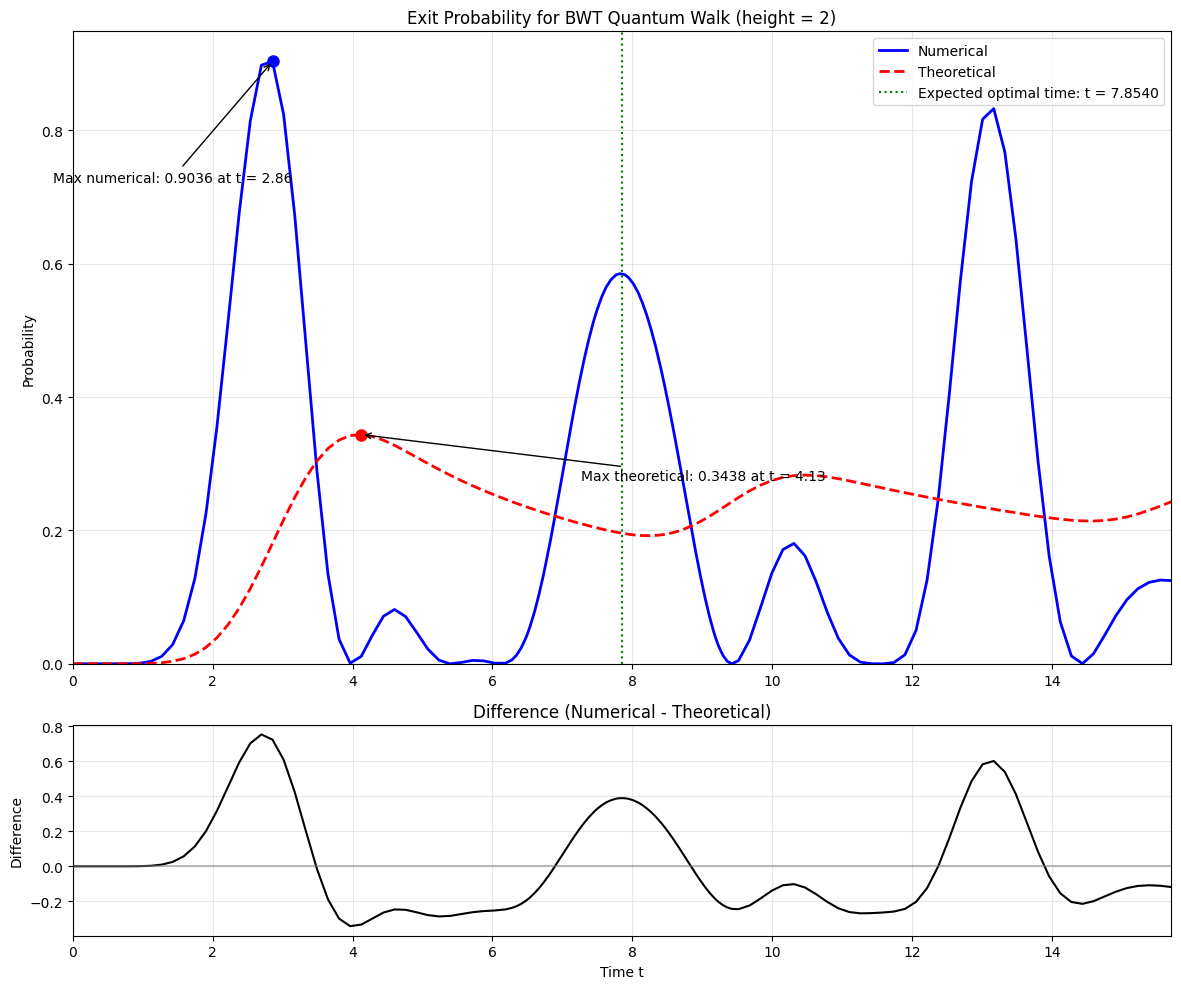

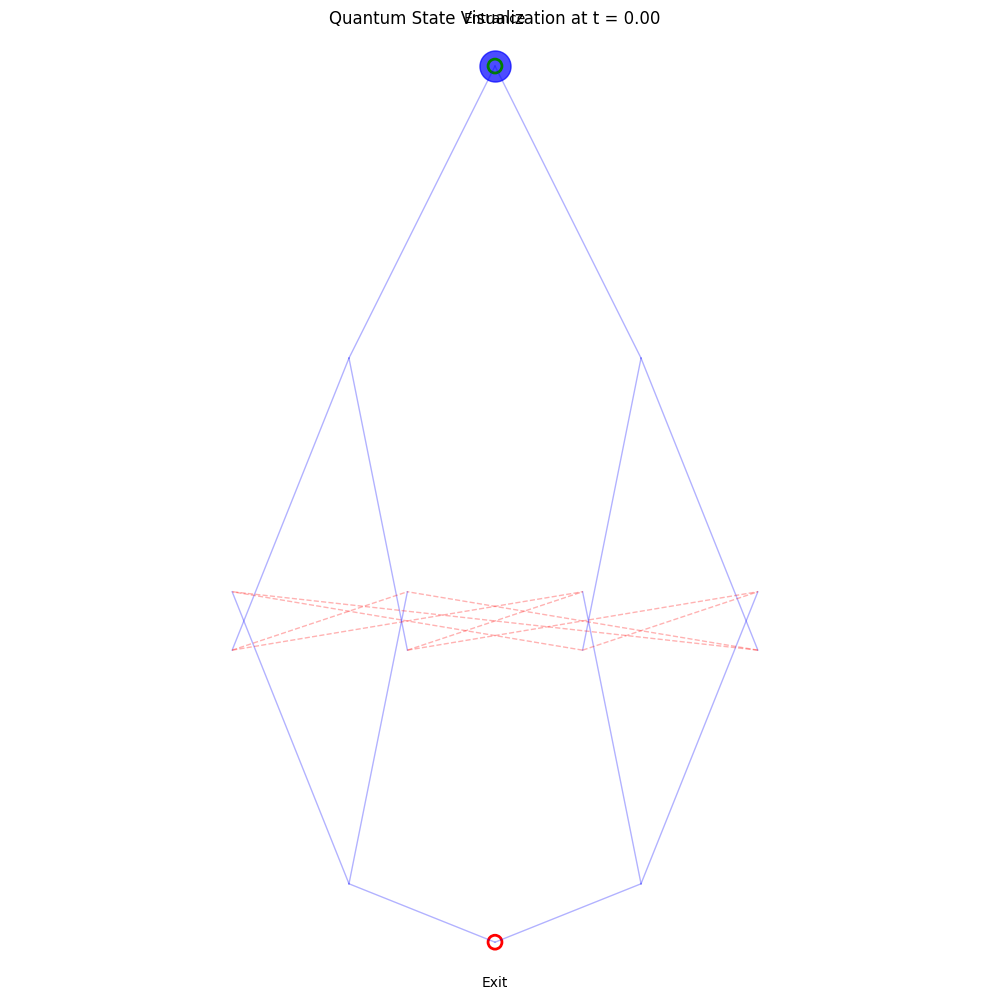

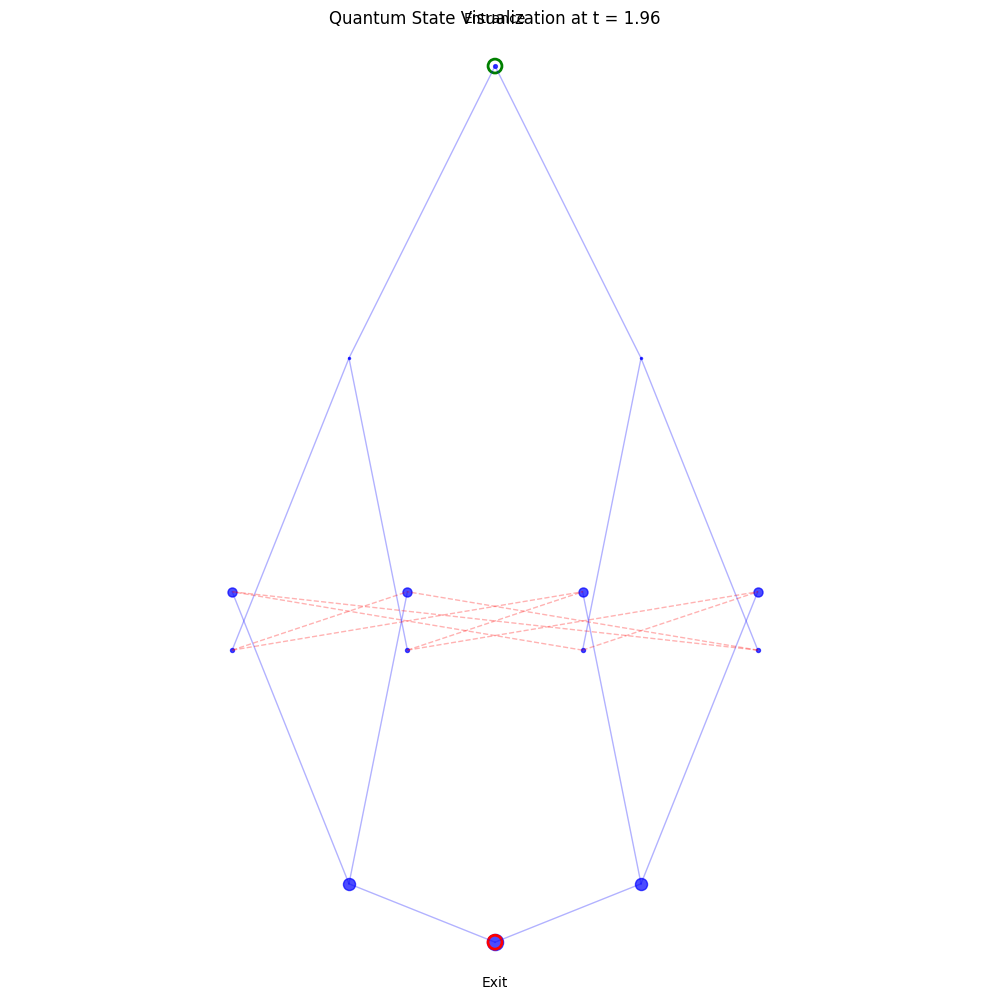

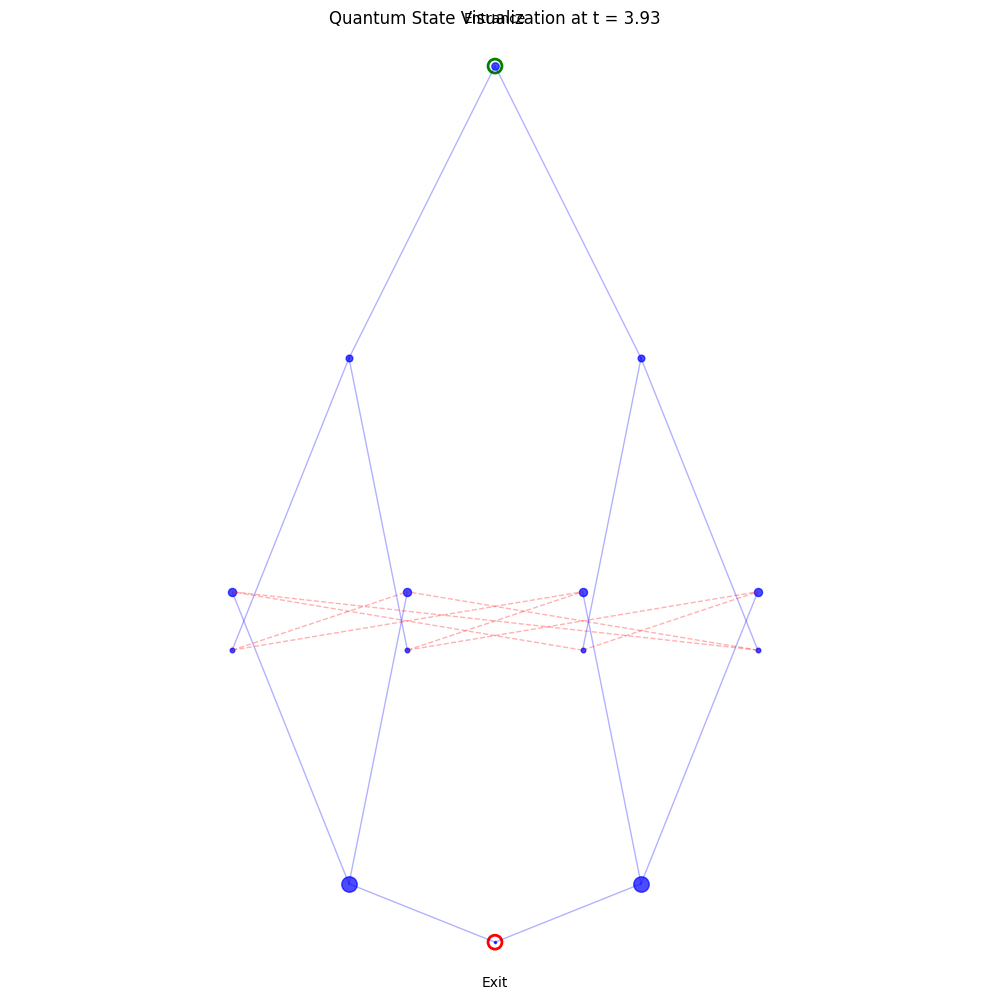

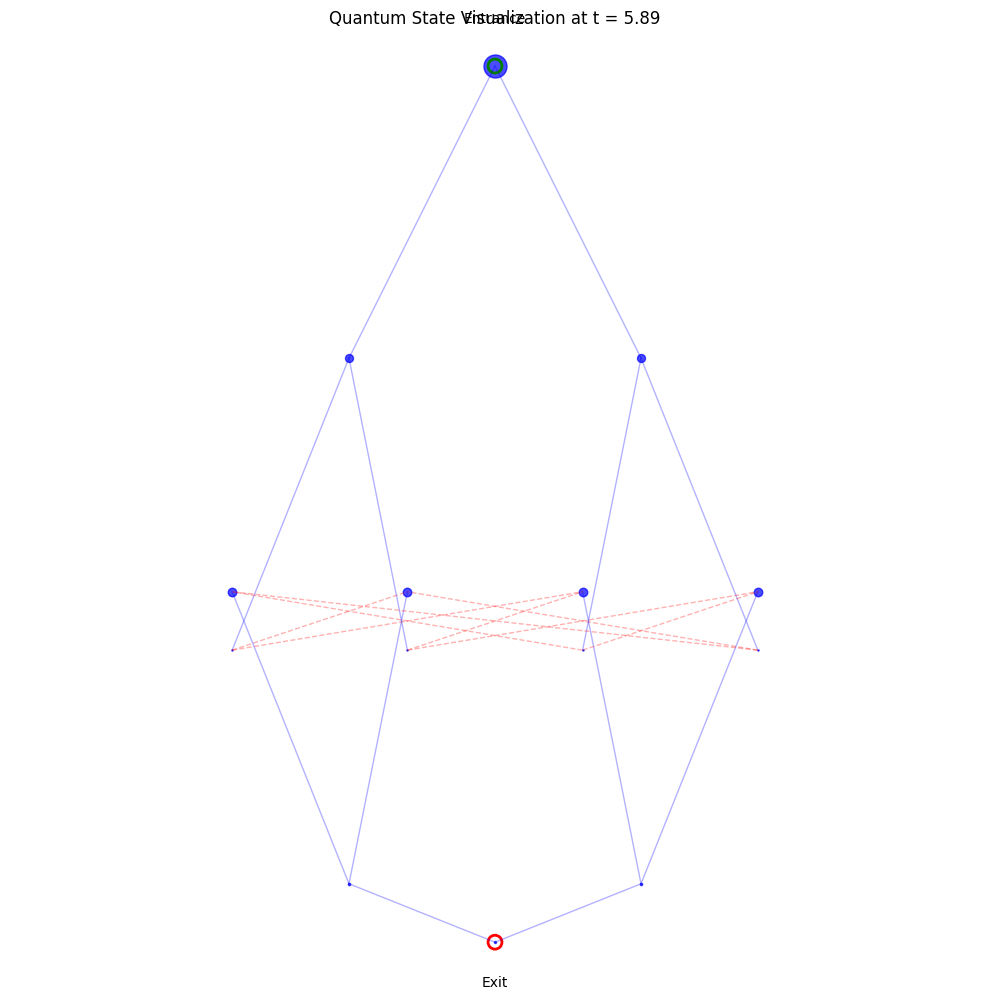

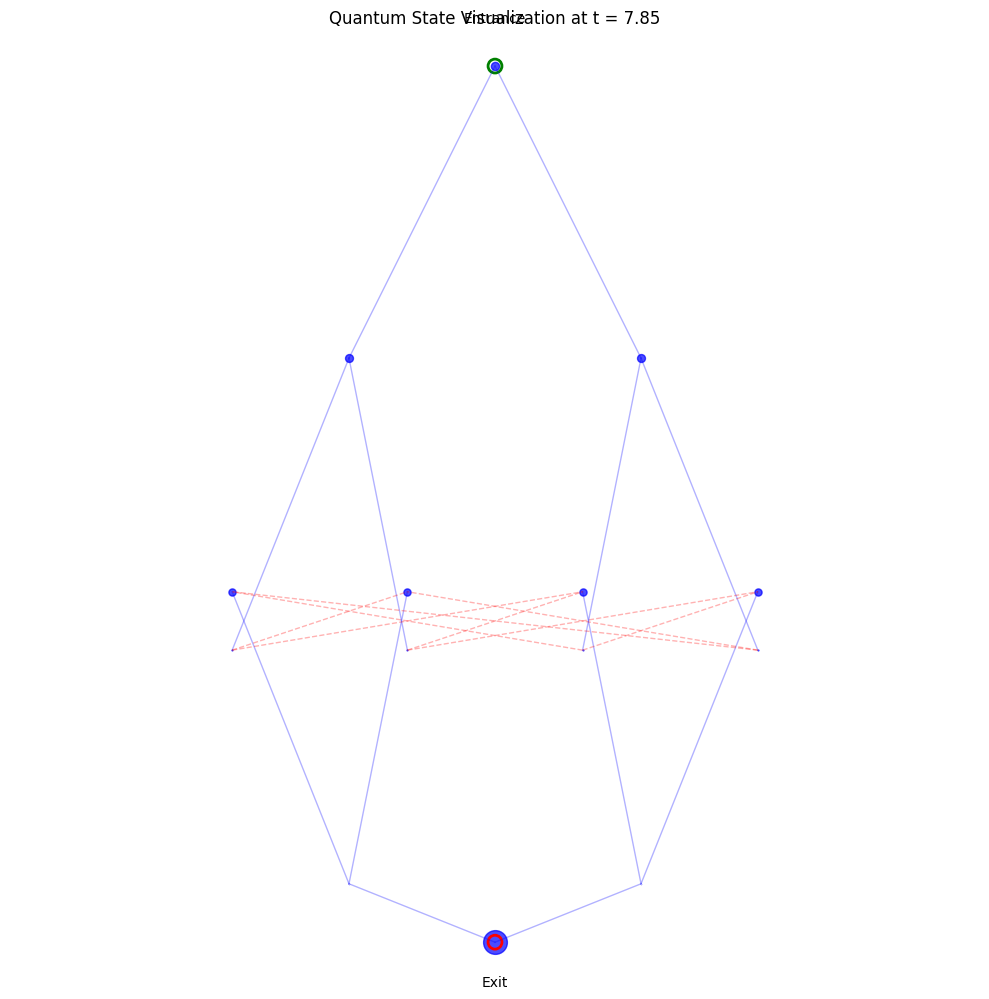

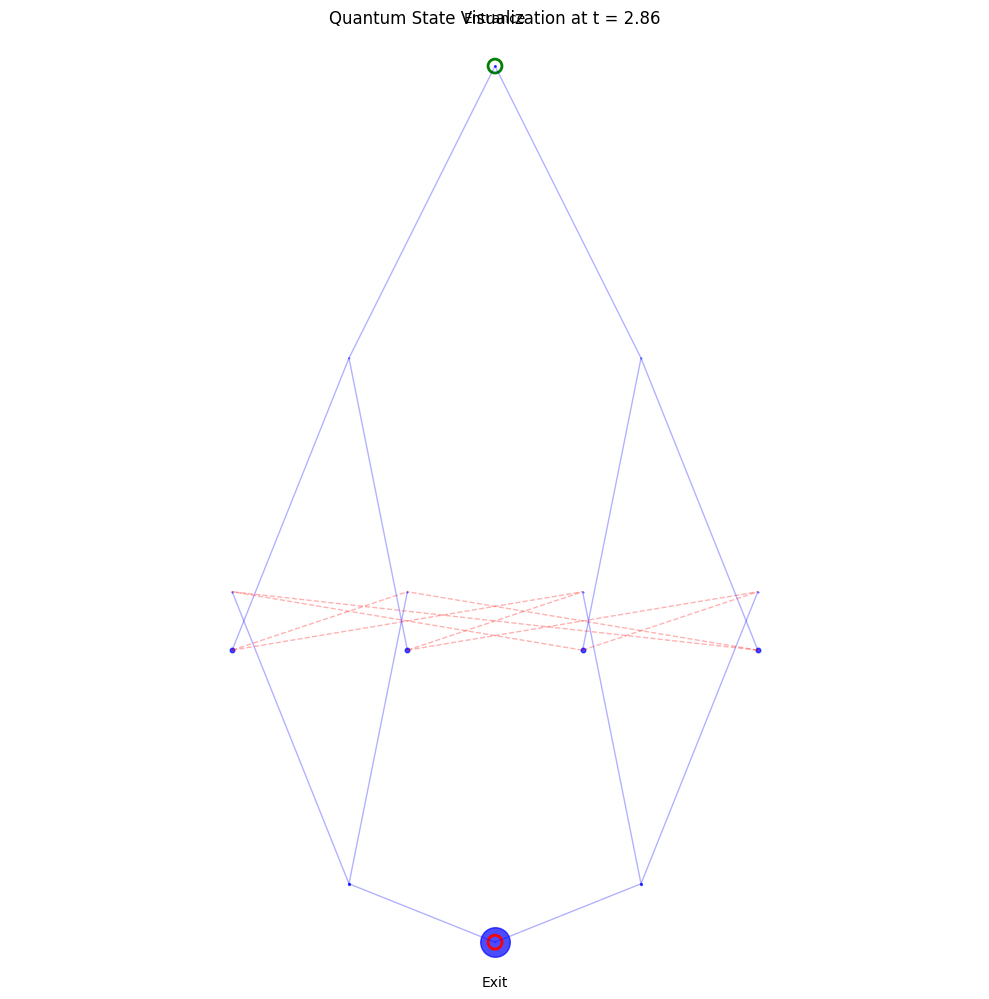

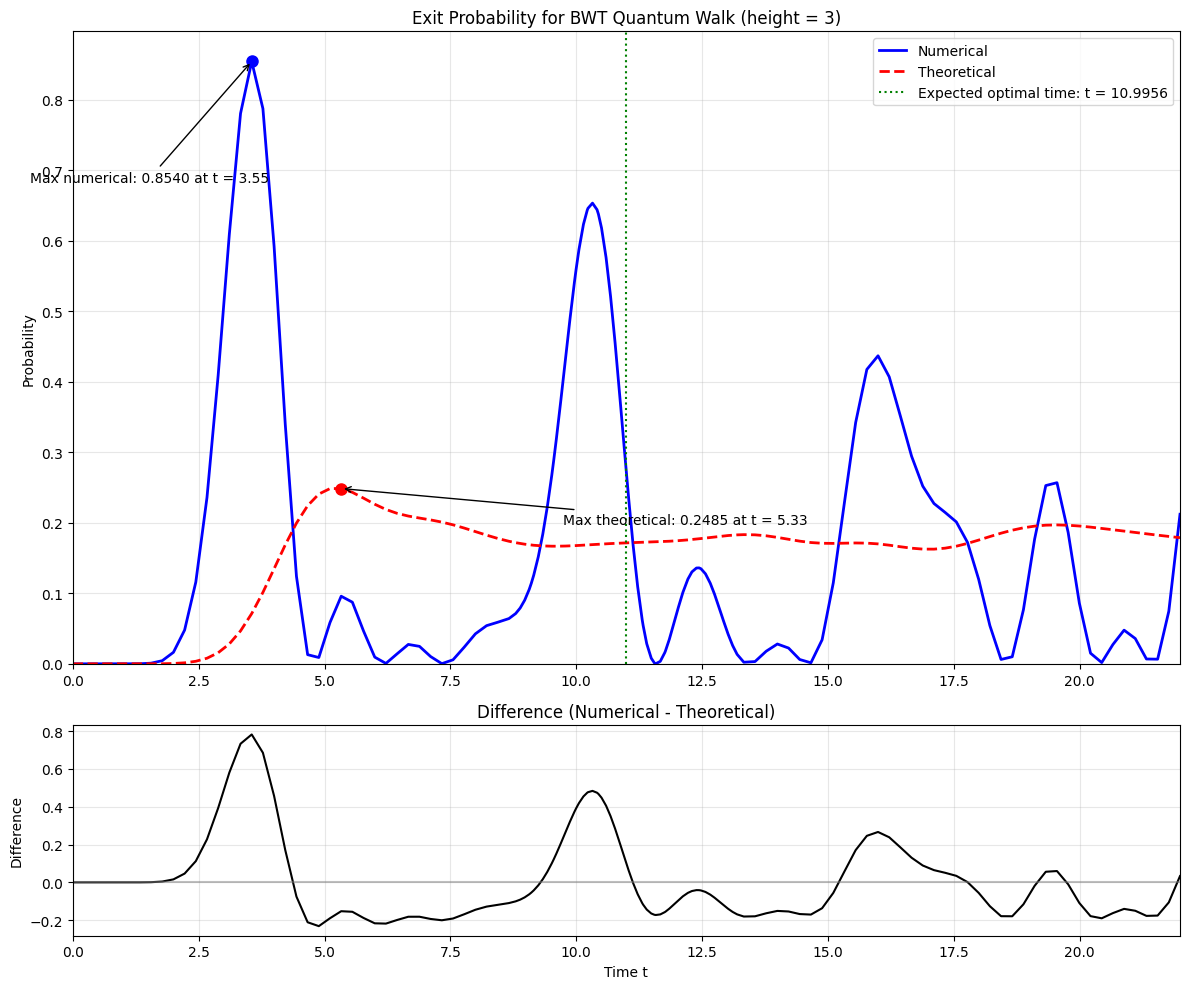

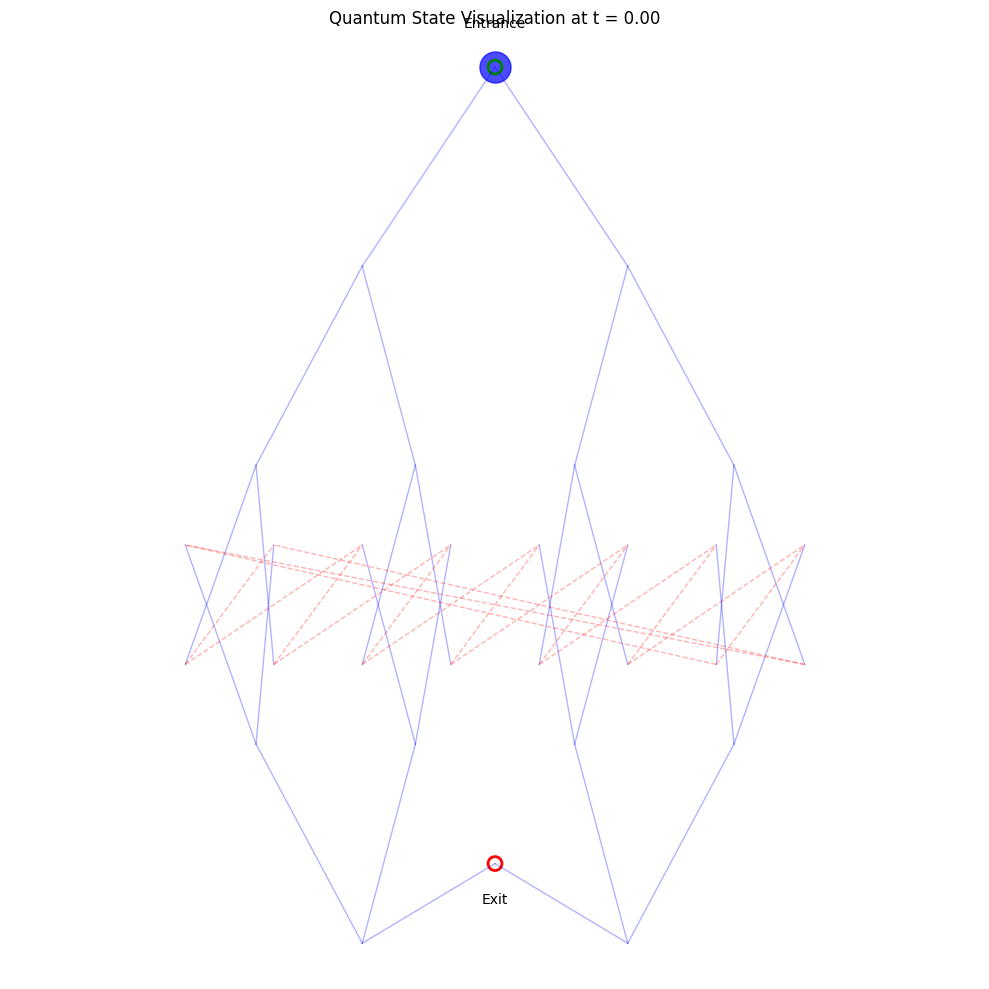

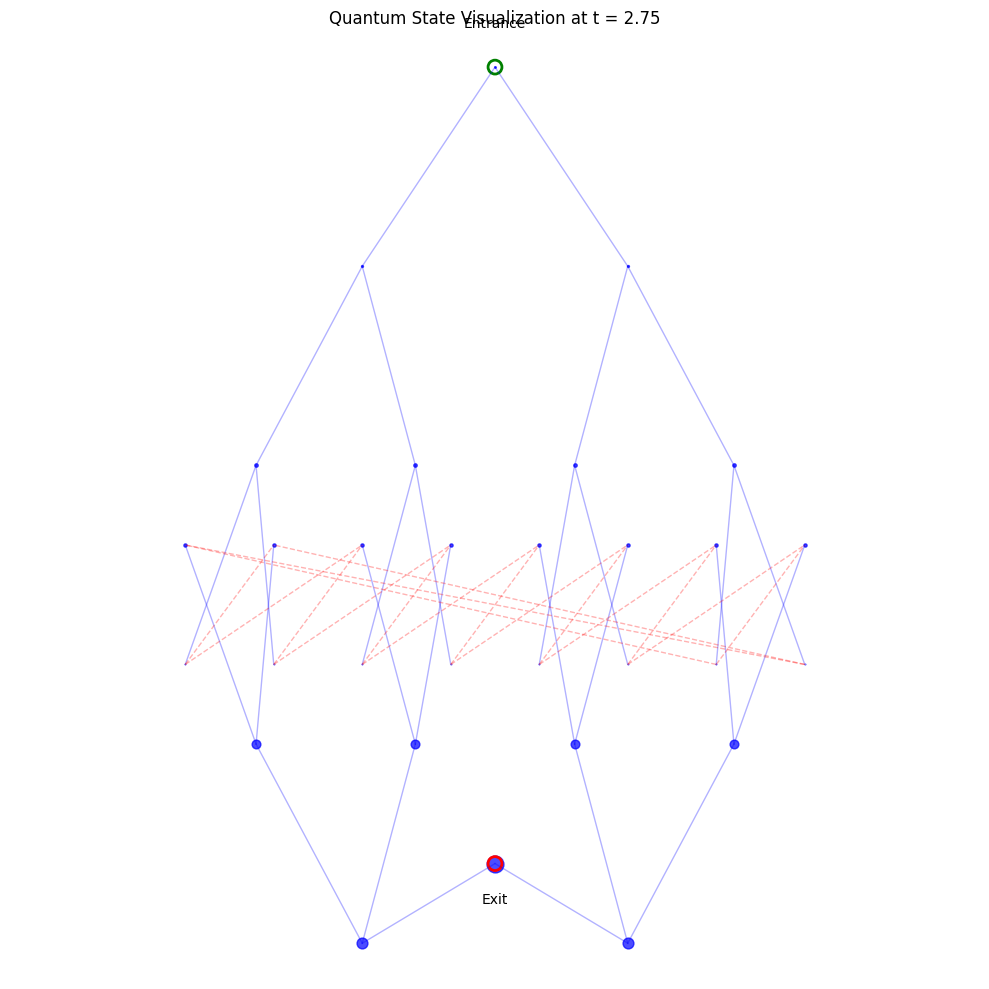

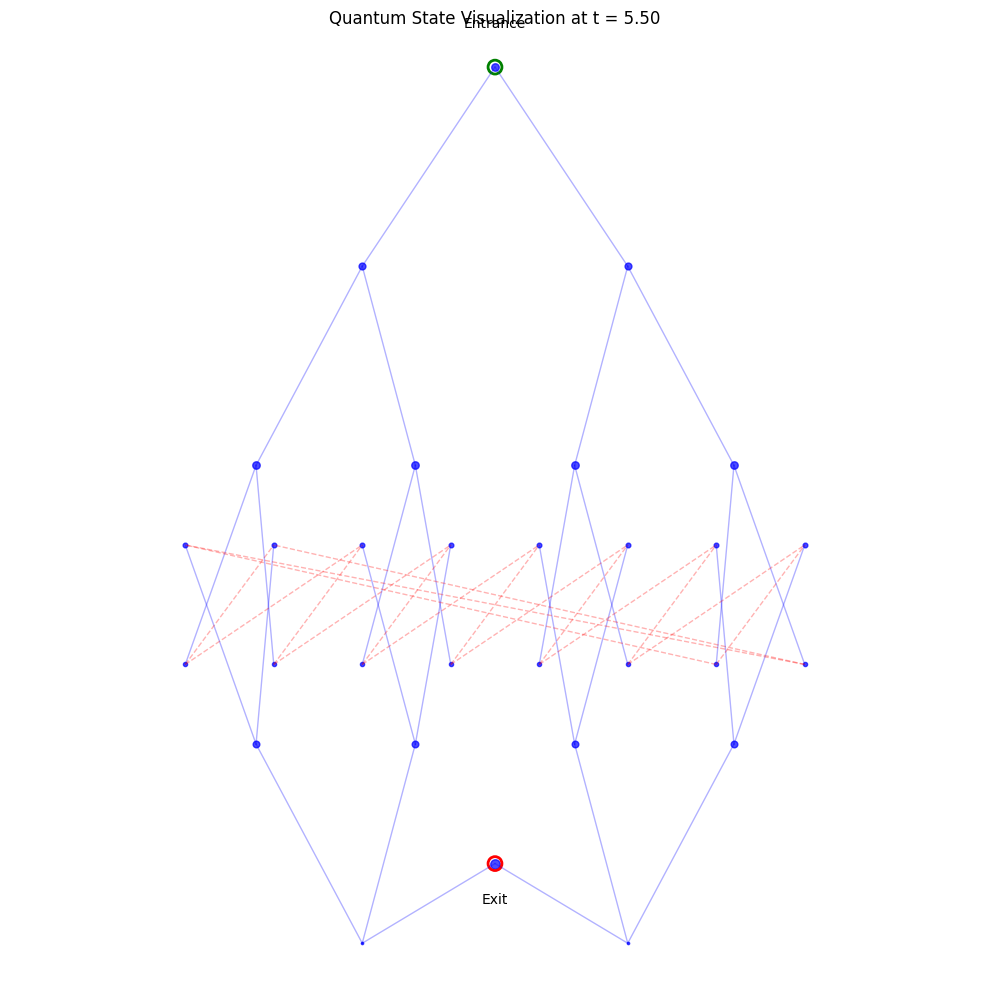

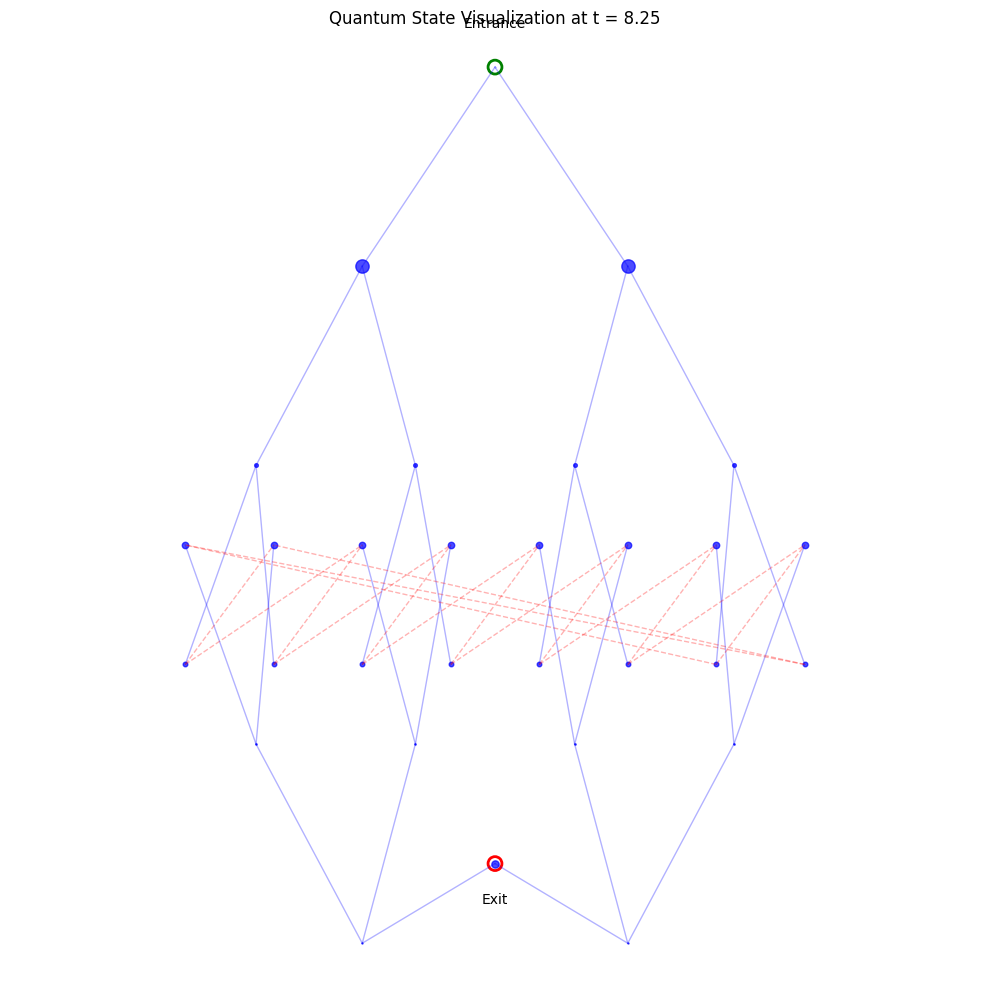

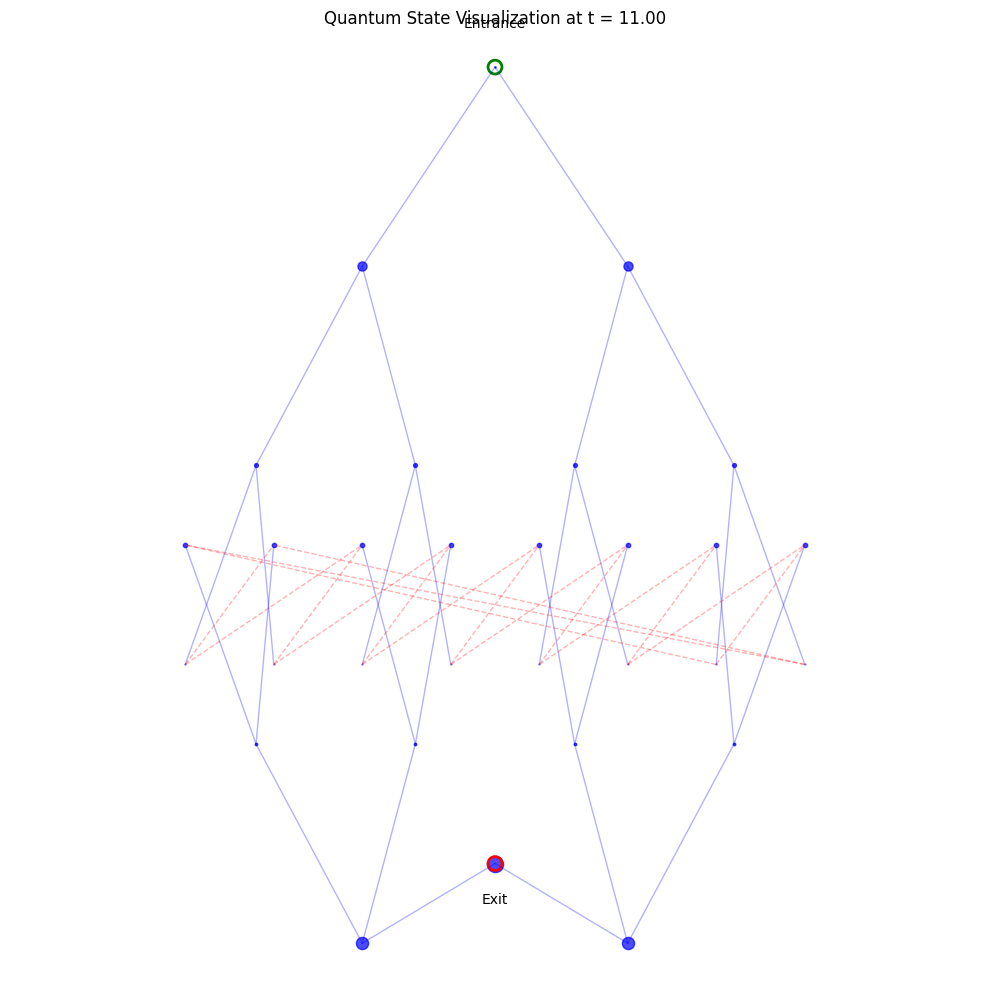

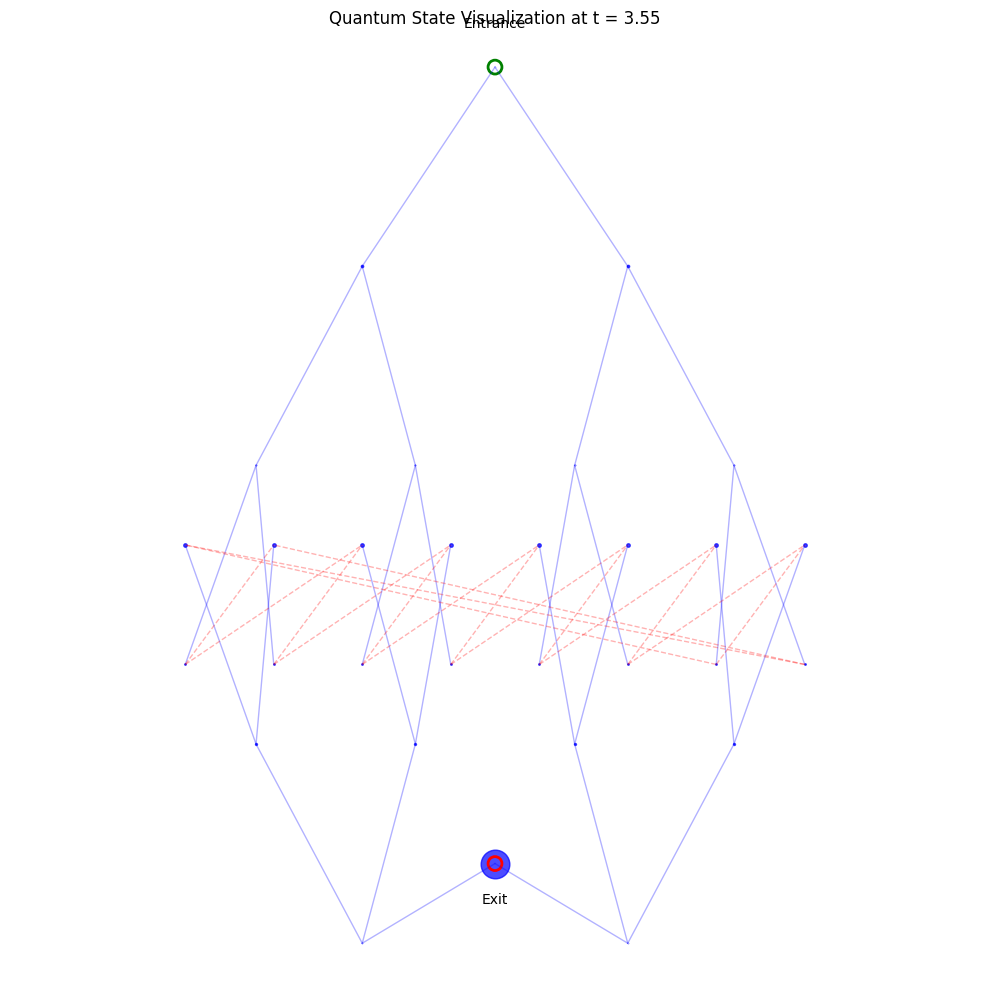

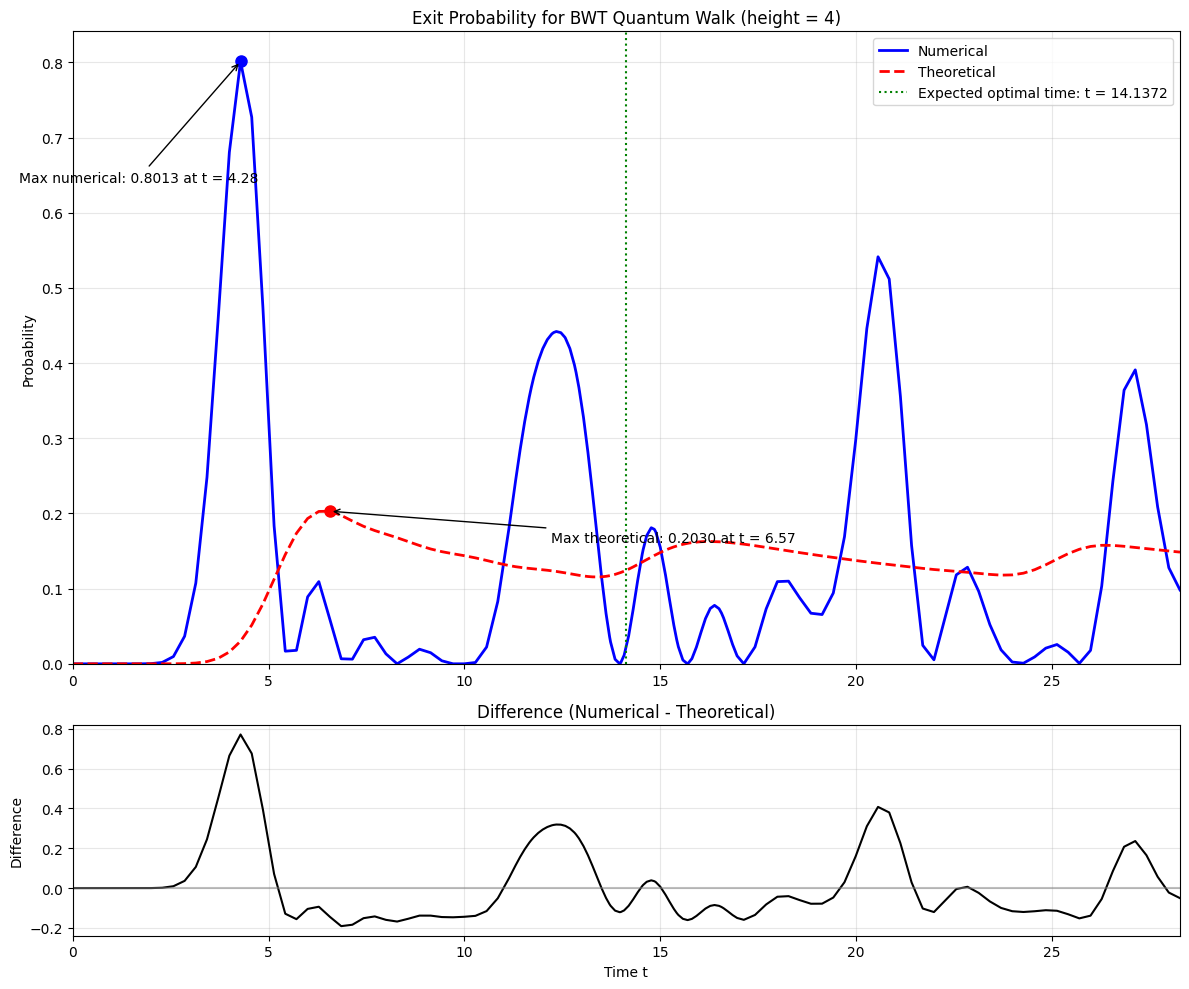

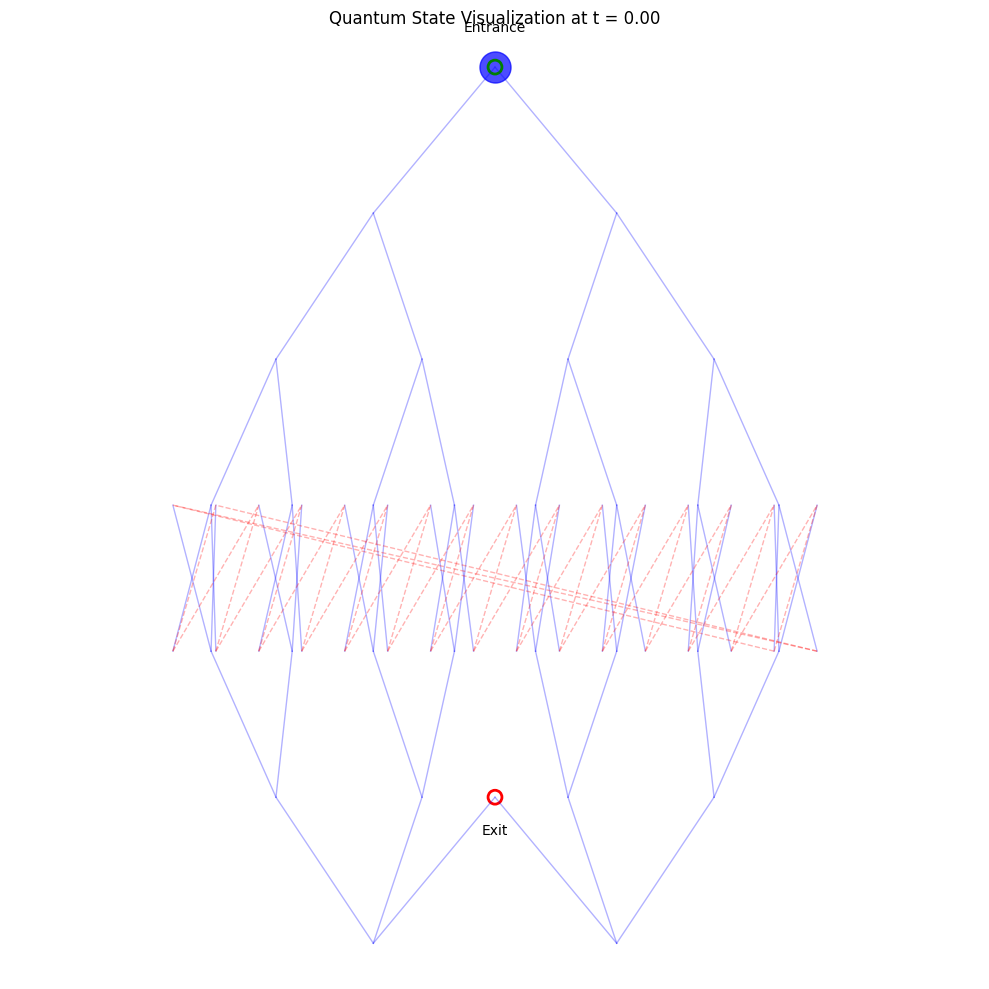

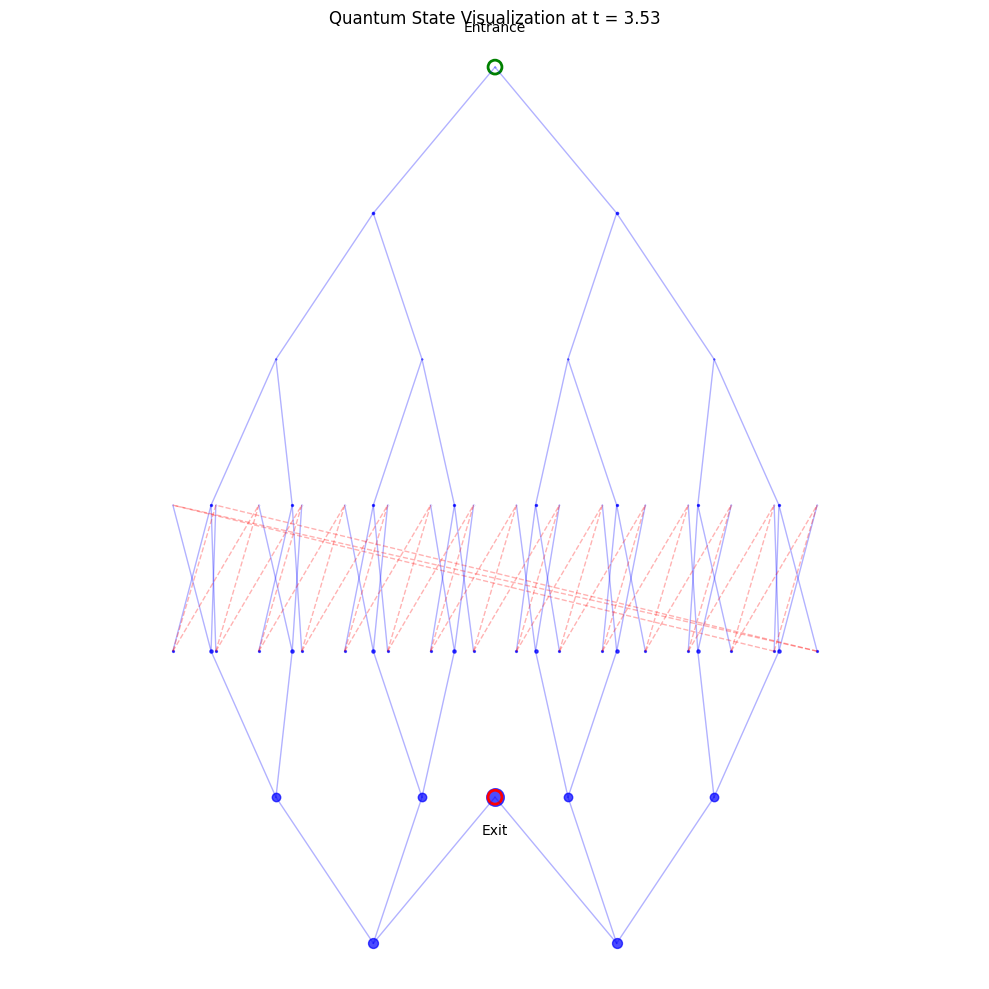

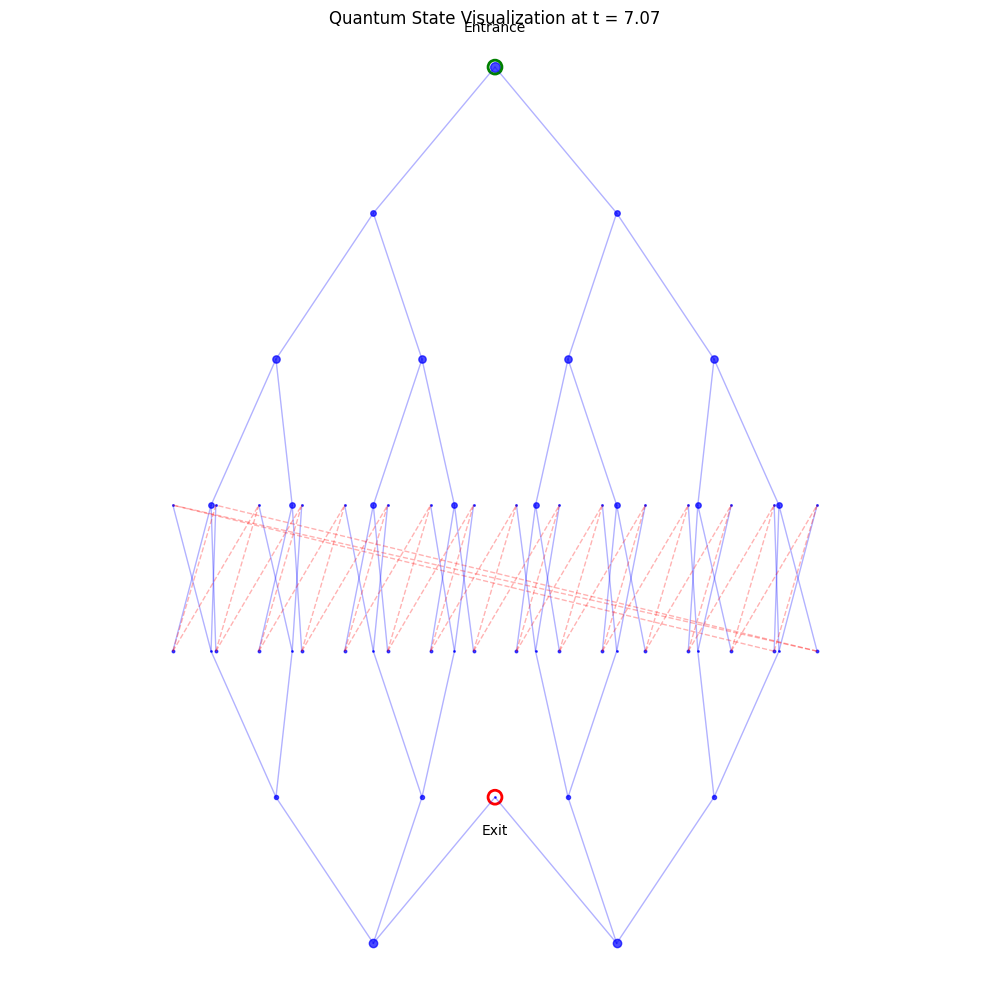

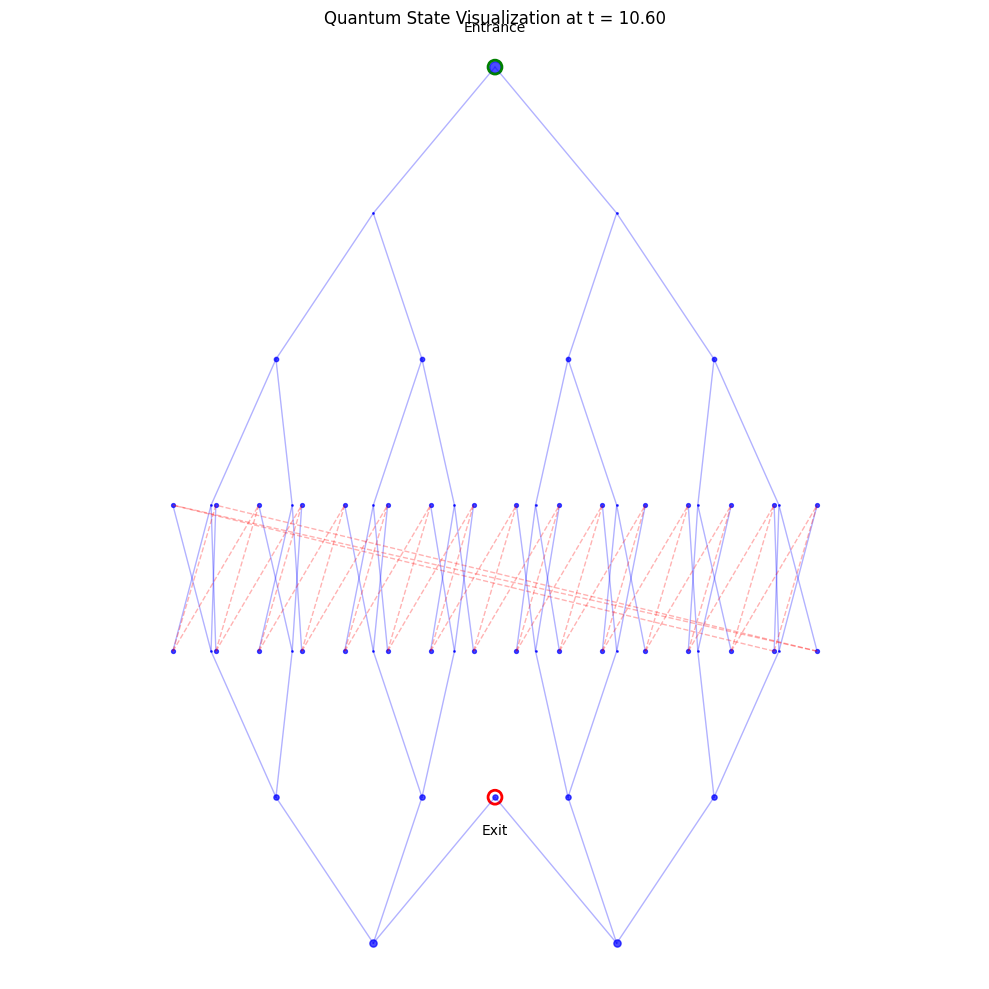

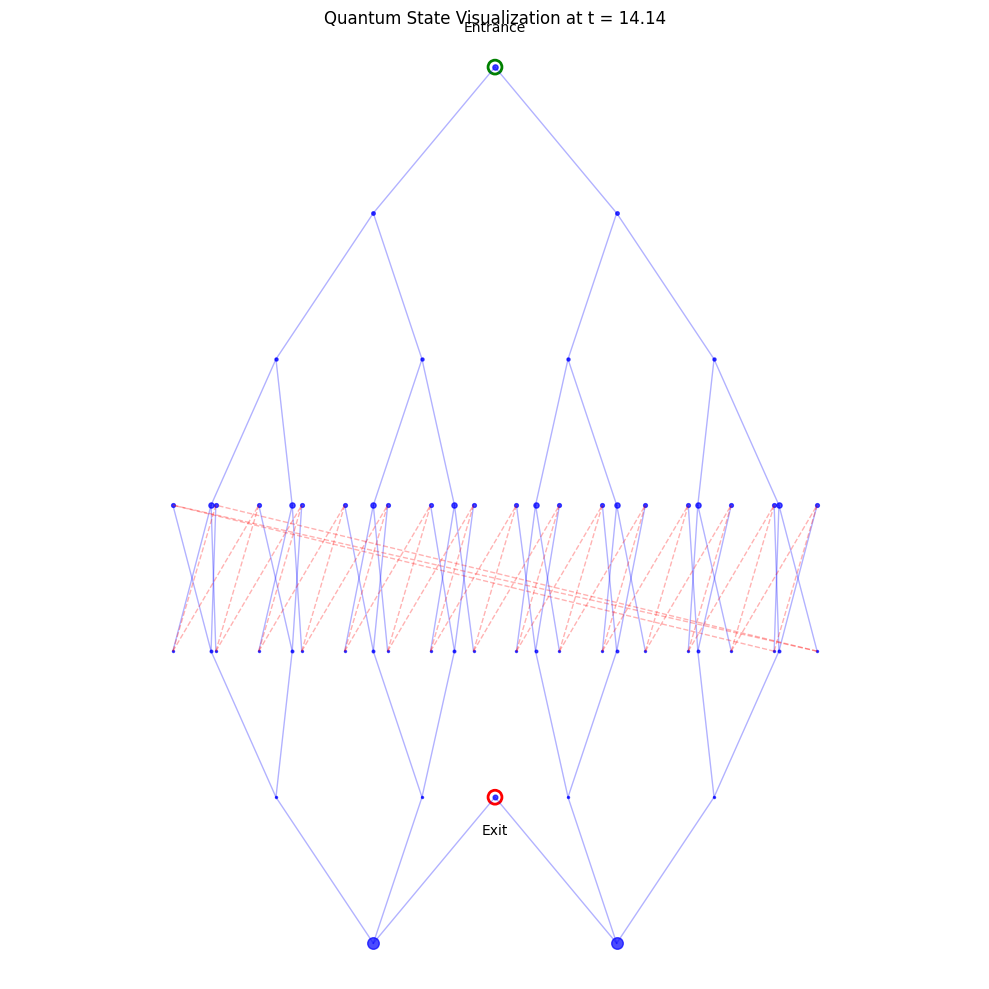

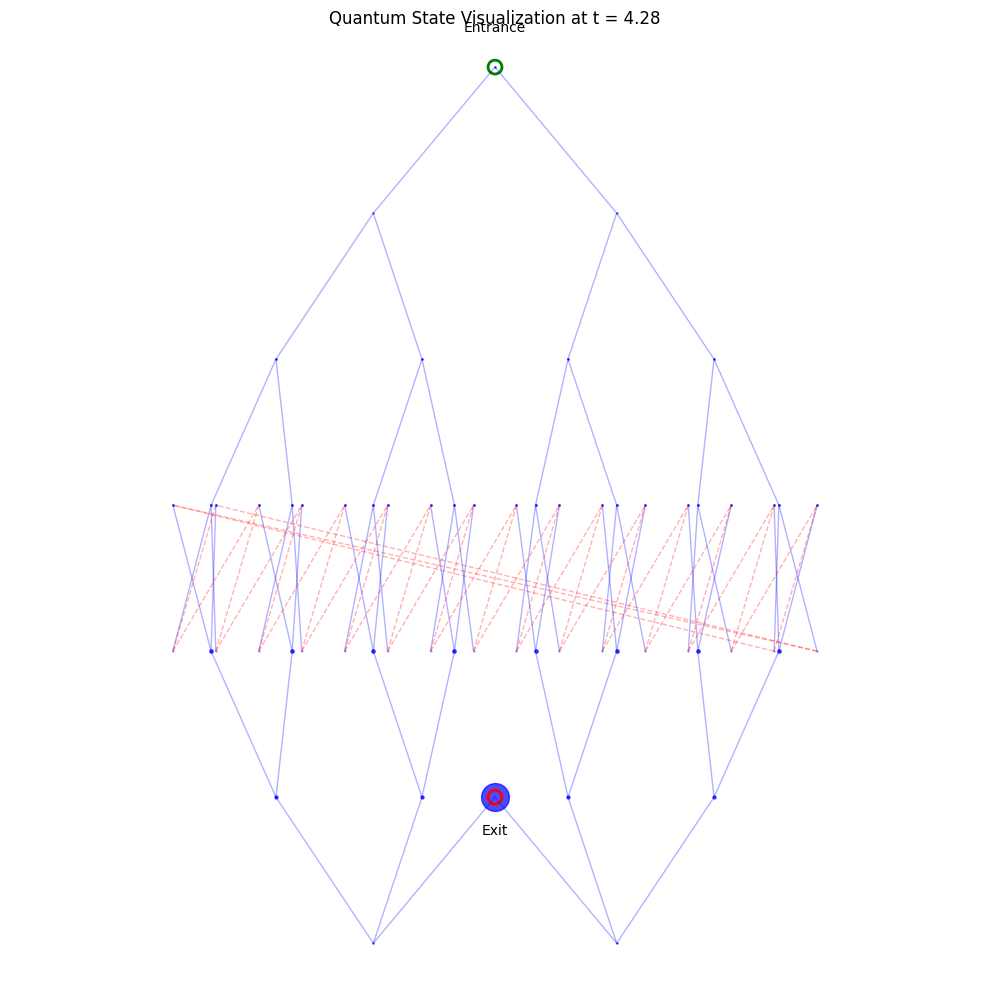

In [4]:
start_time = time.time()
main()
elapsed = time.time() - start_time
print(f"\nTotal execution time: {elapsed:.2f} seconds")